# **Student Mental Health Analysis**
Jyoti Triklani (AU25440)

Lakshita Rathod (AU2544022)

Hardi Makwana (AU2544013)

Siddhi Hirani (AU2544028)

## **Importing Libraries**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

## **Data Loading and Exploring**

In [3]:
df = pd.read_csv('/content/drive/MyDrive/students_mental_health_survey.csv')
print(" Dataset loaded successfully!")

 Dataset loaded successfully!


In [4]:
print("Dataset Shape:", df.shape)

# Total no. of rows and columns
print(f'\nTotal no. of rows: {df.shape[0]}')
print(f'Total no. of columns: {df.shape[1]}\n')

print("First 5 rows of data:")
display(df.head())

Dataset Shape: (7022, 20)

Total no. of rows: 7022
Total no. of columns: 20

First 5 rows of data:


,Age,Course,Gender,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Financial_Stress,Extracurricular_Involvement,Semester_Credit_Load,Residence_Type
0,25,Others,Male,3.56,3,3,2,Good,Moderate,Good,Moderate,Married,Never,Never,No,No,2,Moderate,17,On-Campus
1,24,Engineering,Female,2.44,0,3,0,Average,Low,Average,Low,Single,Occasionally,Occasionally,No,No,3,Low,27,On-Campus
2,19,Business,Female,3.74,4,0,3,Good,Low,Average,Moderate,In a Relationship,Never,Occasionally,No,No,4,High,15,On-Campus
3,19,Computer Science,Male,3.65,2,1,0,Average,Low,Average,Moderate,Single,NaN,Never,No,No,4,Moderate,20,Off-Campus
4,18,Business,Male,3.40,3,3,4,Good,Low,Average,High,Married,Never,Never,No,Yes,0,High,23,On-Campus


In [5]:
print("--- Dataset Info ---")
df.info()

# Statistical Summary for Numerical Columns
print("\n--- Numerical Statistics ---")
display(df.describe())

# Statistical Summary for Categorical Columns (includes count, unique, top, freq)
print("\n--- Categorical Statistics ---")
display(df.describe(include=['O']))

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7022 entries, 0 to 7021
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          7022 non-null   int64  
 1   Course                       7022 non-null   object 
 2   Gender                       7022 non-null   object 
 3   CGPA                         7010 non-null   float64
 4   Stress_Level                 7022 non-null   int64  
 5   Depression_Score             7022 non-null   int64  
 6   Anxiety_Score                7022 non-null   int64  
 7   Sleep_Quality                7022 non-null   object 
 8   Physical_Activity            7022 non-null   object 
 9   Diet_Quality                 7022 non-null   object 
 10  Social_Support               7022 non-null   object 
 11  Relationship_Status          7022 non-null   object 
 12  Substance_Use                7007 non-null   object 
 1

,Age,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Financial_Stress,Semester_Credit_Load
count,7022.000000,7010.00000,7022.000000,7022.000000,7022.000000,7022.000000,7022.000000
mean,23.003418,3.49127,2.427941,2.254486,2.300484,2.453005,22.010538
std,3.853978,0.28742,1.638408,1.625193,1.624305,1.708995,4.358380
min,18.000000,2.44000,0.000000,0.000000,0.000000,0.000000,15.000000
25%,20.000000,3.29000,1.000000,1.000000,1.000000,1.000000,18.000000
50%,22.000000,3.50000,2.000000,2.000000,2.000000,2.000000,22.000000
75%,25.000000,3.70000,4.000000,3.000000,4.000000,4.000000,26.000000
max,35.000000,4.00000,5.000000,5.000000,5.000000,5.000000,29.000000



--- Categorical Statistics ---


,Course,Gender,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Extracurricular_Involvement,Residence_Type
count,7022,7022,7022,7022,7022,7022,7022,7007,7022,7022,7022,7022,7022
unique,6,2,3,3,3,3,3,3,3,2,2,3,3
top,Medical,Male,Good,Moderate,Average,Moderate,Single,Never,Never,No,No,Moderate,On-Campus
freq,2105,3547,3589,3521,4268,3470,3574,5903,4263,4866,6678,3440,2815


In [6]:
# Identify Numerical and Categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(" Numerical Features:")
print(numerical_cols)
print("\n🔤Categorical Features:")
print(categorical_cols)

 Numerical Features:
['Age', 'CGPA', 'Stress_Level', 'Depression_Score', 'Anxiety_Score', 'Financial_Stress', 'Semester_Credit_Load']

🔤Categorical Features:
['Course', 'Gender', 'Sleep_Quality', 'Physical_Activity', 'Diet_Quality', 'Social_Support', 'Relationship_Status', 'Substance_Use', 'Counseling_Service_Use', 'Family_History', 'Chronic_Illness', 'Extracurricular_Involvement', 'Residence_Type']


In [7]:
# Inspect Unique Values in Categorical Features

print("--- Unique Values in Categorical Columns ---")

for col in categorical_cols:
    unique_count = df[col].nunique()

    # If the number of unique values is small (< 50), print them out
    if unique_count < 50:
        print(f"\nFeature: '{col}' has {unique_count} unique values:")
        print(df[col].unique())

    # If there are too many unique values (like Name or Host Name), just print the count
    else:
        print(f"\nFeature: '{col}' has {unique_count} unique values (Too many to list individually)")

--- Unique Values in Categorical Columns ---

Feature: 'Course' has 6 unique values:
['Others' 'Engineering' 'Business' 'Computer Science' 'Medical' 'Law']

Feature: 'Gender' has 2 unique values:
['Male' 'Female']

Feature: 'Sleep_Quality' has 3 unique values:
['Good' 'Average' 'Poor']

Feature: 'Physical_Activity' has 3 unique values:
['Moderate' 'Low' 'High']

Feature: 'Diet_Quality' has 3 unique values:
['Good' 'Average' 'Poor']

Feature: 'Social_Support' has 3 unique values:
['Moderate' 'Low' 'High']

Feature: 'Relationship_Status' has 3 unique values:
['Married' 'Single' 'In a Relationship']

Feature: 'Substance_Use' has 3 unique values:
['Never' 'Occasionally' nan 'Frequently']

Feature: 'Counseling_Service_Use' has 3 unique values:
['Never' 'Occasionally' 'Frequently']

Feature: 'Family_History' has 2 unique values:
['No' 'Yes']

Feature: 'Chronic_Illness' has 2 unique values:
['No' 'Yes']

Feature: 'Extracurricular_Involvement' has 3 unique values:
['Moderate' 'Low' 'High']

Fe

## **Handling Missing Values**

In [8]:
# --- 1. Calculate Missing Values ---
missing_values_count = df.isnull().sum()
missing_percentage = (missing_values_count / len(df)) * 100

# --- 2. Create Summary DataFrame ---
missing_data_summary = pd.DataFrame({
    'Column Name': df.columns,
    'Missing Value Count': missing_values_count.values,
    'Missing Value Percentage': missing_percentage.values
})

# Sort by percentage descending to spot the worst columns easily
missing_data_summary = missing_data_summary.sort_values(by='Missing Value Percentage', ascending=False)

# Round percentage for cleaner display
missing_data_summary['Missing Value Percentage'] = missing_data_summary['Missing Value Percentage'].round(2)

print("--- Missing Data Summary Table ---")
# Reset index to hide the original index numbers for a cleaner look
display(missing_data_summary.reset_index(drop=True))

--- Missing Data Summary Table ---


,Column Name,Missing Value Count,Missing Value Percentage
0,Substance_Use,15,0.21
1,CGPA,12,0.17
2,Course,0,0.00
3,Age,0,0.00
4,Gender,0,0.00
5,Stress_Level,0,0.00
6,Anxiety_Score,0,0.00
7,Depression_Score,0,0.00
8,Physical_Activity,0,0.00
9,Diet_Quality,0,0.00


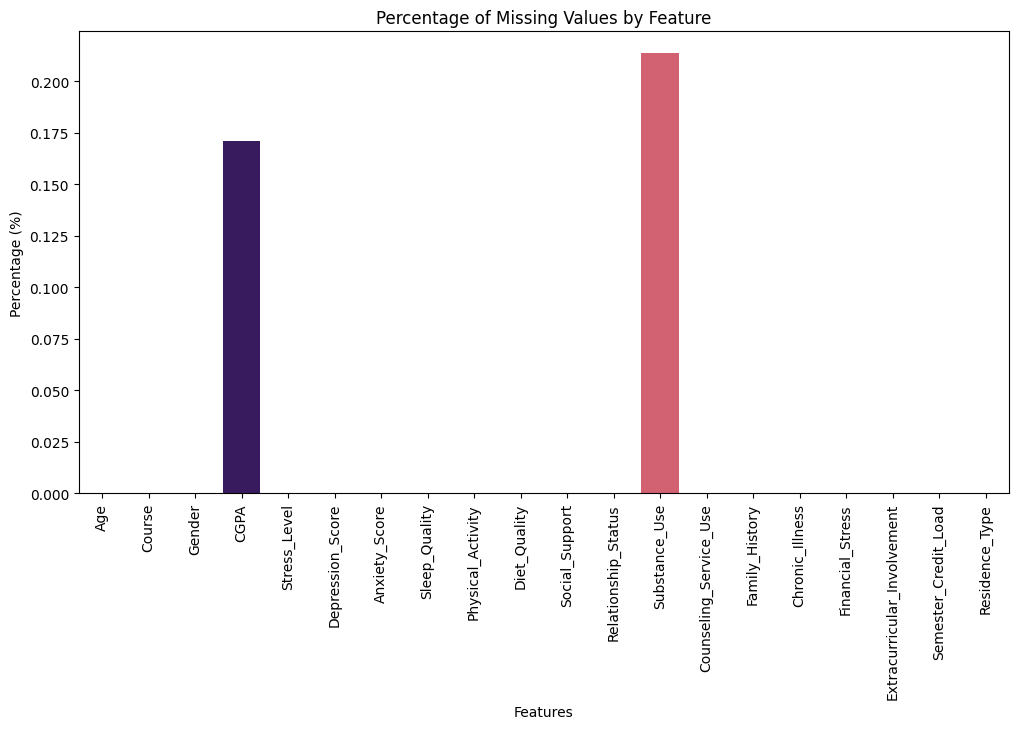

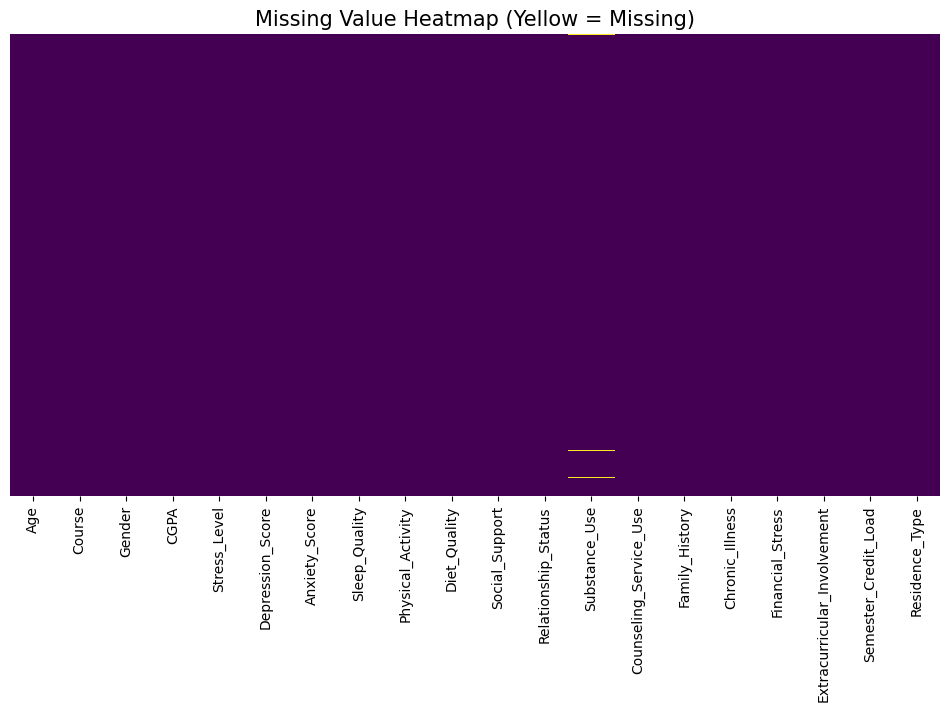

In [9]:
# --- Visualization 1: Bar Plot of Missing Counts ---
# Filter only columns that have missing values to keep the plot clean

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percentage.index, y=missing_percentage.values, hue=missing_percentage.index, palette='magma')
plt.xticks(rotation=90)
plt.title('Percentage of Missing Values by Feature')
plt.ylabel('Percentage (%)')
plt.xlabel('Features')
plt.show()

# --- Visualization 2: Heatmap of Missing Data ---
# This helps see if missing values in different columns are related
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (Yellow = Missing)', fontsize=15)
plt.show()

### **Imputation**
#### Median Imputation

In [10]:
# --- 1. Handling Missing CGPA - Numerical Data ---
median_val = df['CGPA'].median()
df['CGPA'] = df['CGPA'].fillna(median_val)
print(f"Filled missing values in 'CGPA' with median: {median_val}")

Filled missing values in 'CGPA' with median: 3.5


In [11]:
# --- 2. Handling Missing Substance_Use	- Categorical Data ---
mode_val = df['Substance_Use'].mode()[0]
df['Substance_Use'] = df['Substance_Use'].fillna(mode_val)
print(f"Filled missing values in 'Substance_Use' with median: {mode_val}")

Filled missing values in 'Substance_Use' with median: Never


In [12]:
# --- 3. Validation ---
print("Final Dataset Shape:", df.shape)

# Total no. of rows and columns
print(f'\nTotal no. of rows: {df.shape[0]}')
print(f'Total no. of columns: {df.shape[1]}\n')

# missing values
print("Remaining Missing Values:", df.isnull().sum().sum())

print()
# dataset information including column names, data types, and non-null counts
df.info()

Final Dataset Shape: (7022, 20)

Total no. of rows: 7022
Total no. of columns: 20

Remaining Missing Values: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7022 entries, 0 to 7021
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          7022 non-null   int64  
 1   Course                       7022 non-null   object 
 2   Gender                       7022 non-null   object 
 3   CGPA                         7022 non-null   float64
 4   Stress_Level                 7022 non-null   int64  
 5   Depression_Score             7022 non-null   int64  
 6   Anxiety_Score                7022 non-null   int64  
 7   Sleep_Quality                7022 non-null   object 
 8   Physical_Activity            7022 non-null   object 
 9   Diet_Quality                 7022 non-null   object 
 10  Social_Support               7022 non-null   object 
 11  Relationship_Status   

## **EDA - Exploratary Data Analysis**
### **Case 1: Mental Health Distribution**

* To understand the shape of primary target variables: `Stress_Level`, `Depression_Score`, and `Anxiety_Score`

* Check if primary target features are sekwed or not?

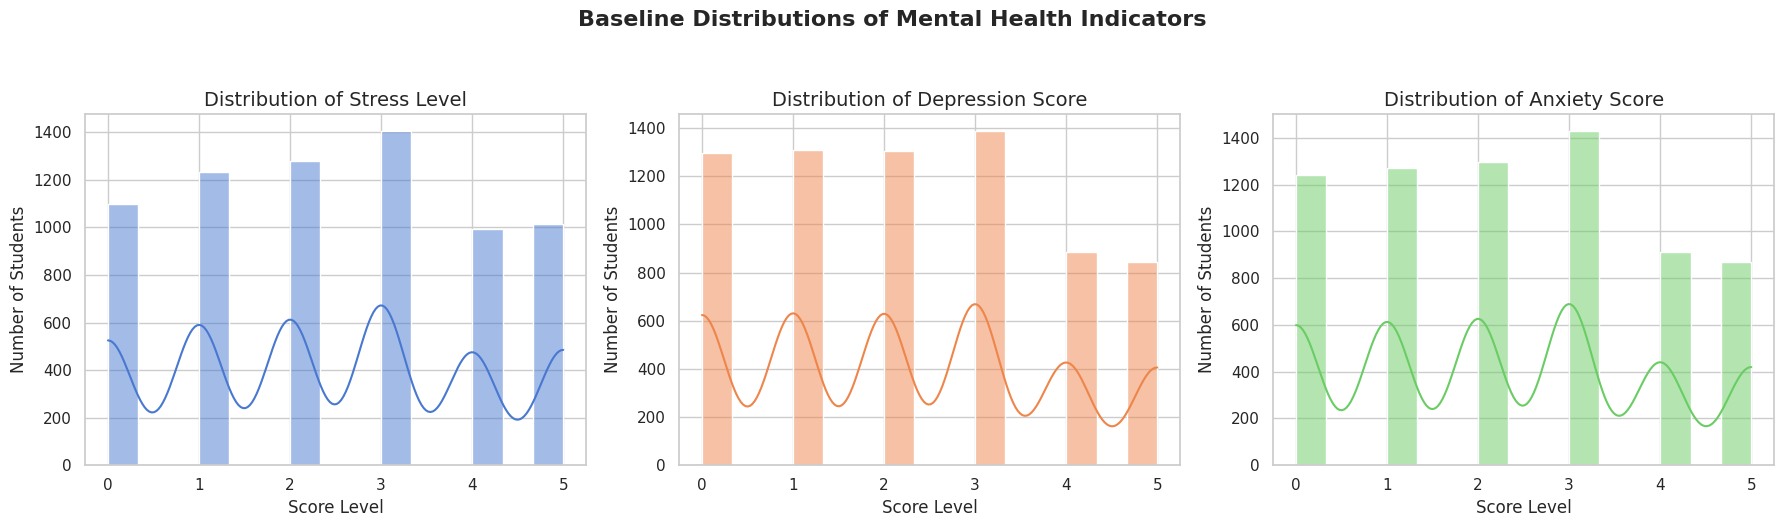

In [13]:
# Set a clean visual style for the analysis
sns.set_theme(style="whitegrid")

# Define the primary target metrics we want to explore
mental_health_metrics = ['Stress_Level', 'Depression_Score', 'Anxiety_Score']

# Create a wide figure to hold three side-by-side plots
distribution_figure, subplot_axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
distribution_figure.suptitle('Baseline Distributions of Mental Health Indicators', fontsize=16, fontweight='bold', y=1.05)

# Loop through each metric to build its respective histogram and density curve
for index, metric_name in enumerate(mental_health_metrics):

    # Plot the histogram with a KDE curve overlay
    sns.histplot(
        data=df, # Assuming your cleaned dataframe is still named 'df'
        x=metric_name,
        kde=True,
        ax=subplot_axes[index],
        color=sns.color_palette("muted")[index],
        bins=15 # Adjust bin count if the scores have a wider/narrower range
    )

    # Format the titles and labels for clarity
    readable_title = metric_name.replace('_', ' ')
    subplot_axes[index].set_title(f'Distribution of {readable_title}', fontsize=14)
    subplot_axes[index].set_xlabel('Score Level', fontsize=12)
    subplot_axes[index].set_ylabel('Number of Students', fontsize=12)

# Ensure the subplots are cleanly spaced
plt.tight_layout()
plt.show()

### **Case 2: Academics vs. Mental Health**

* Plot `Semester_Credit_Load` against `Stress_Level` and `Anxiety_Score`

* check if higher credits taken by students will it result in higer stress

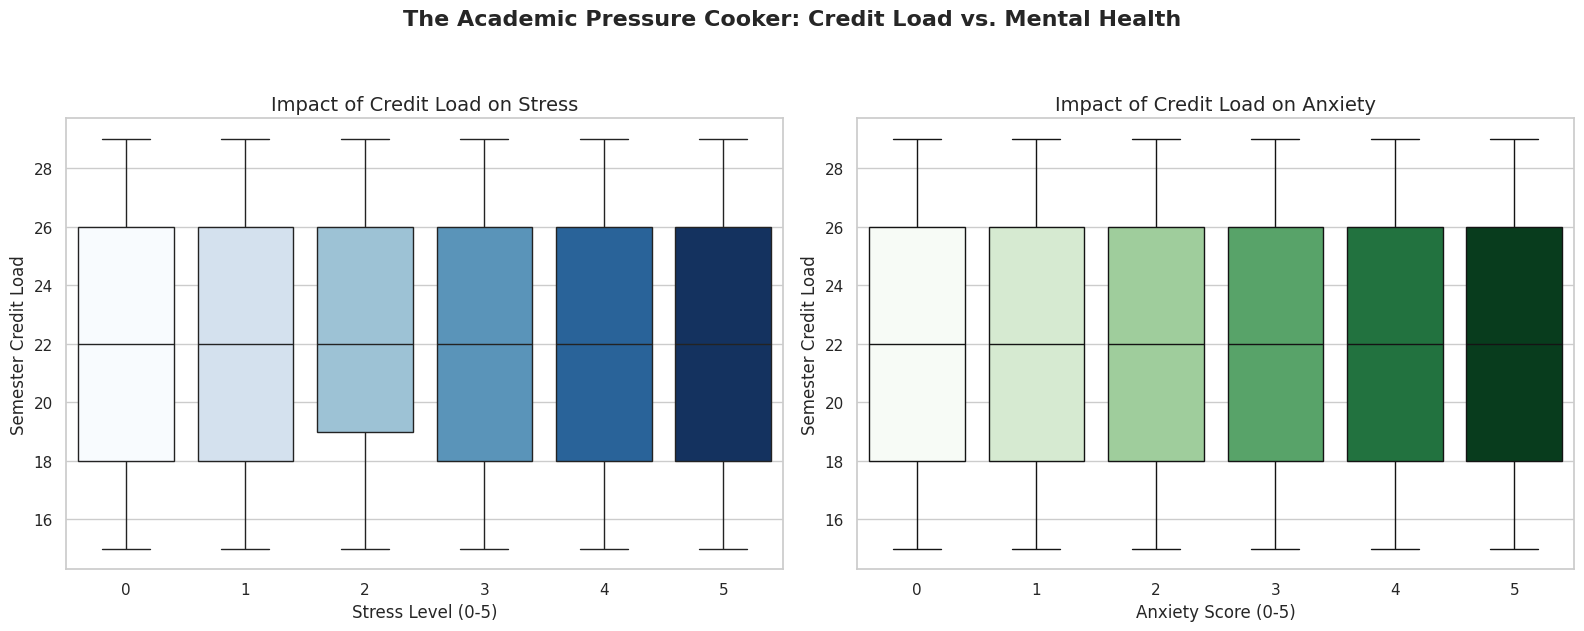

In [14]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('The Academic Pressure Cooker: Credit Load vs. Mental Health', fontsize=16, fontweight='bold', y=1.05)

# Plot 1: Stress Level vs Credit Load
sns.boxplot(
    ax=axes[0],
    data=df,
    x='Stress_Level',
    y='Semester_Credit_Load',
    hue='Stress_Level',
    palette='Blues',
    legend=False
)
axes[0].set_title('Impact of Credit Load on Stress', fontsize=14)
axes[0].set_xlabel('Stress Level (0-5)', fontsize=12)
axes[0].set_ylabel('Semester Credit Load', fontsize=12)

# Plot 2: Anxiety Score vs Credit Load
sns.boxplot(
    ax=axes[1],
    data=df,
    x='Anxiety_Score',
    y='Semester_Credit_Load',
    hue='Anxiety_Score',
    palette='Greens',
    legend=False
)
axes[1].set_title('Impact of Credit Load on Anxiety', fontsize=14)
axes[1].set_xlabel('Anxiety Score (0-5)', fontsize=12)
axes[1].set_ylabel('Semester Credit Load', fontsize=12)

plt.tight_layout()
plt.show()

### **Case 3: Habit vs. Target**

* Addresses the lifestyle habits.

* Identify if poor sleep is stronger trigger for stress than poor diet, or vice versa

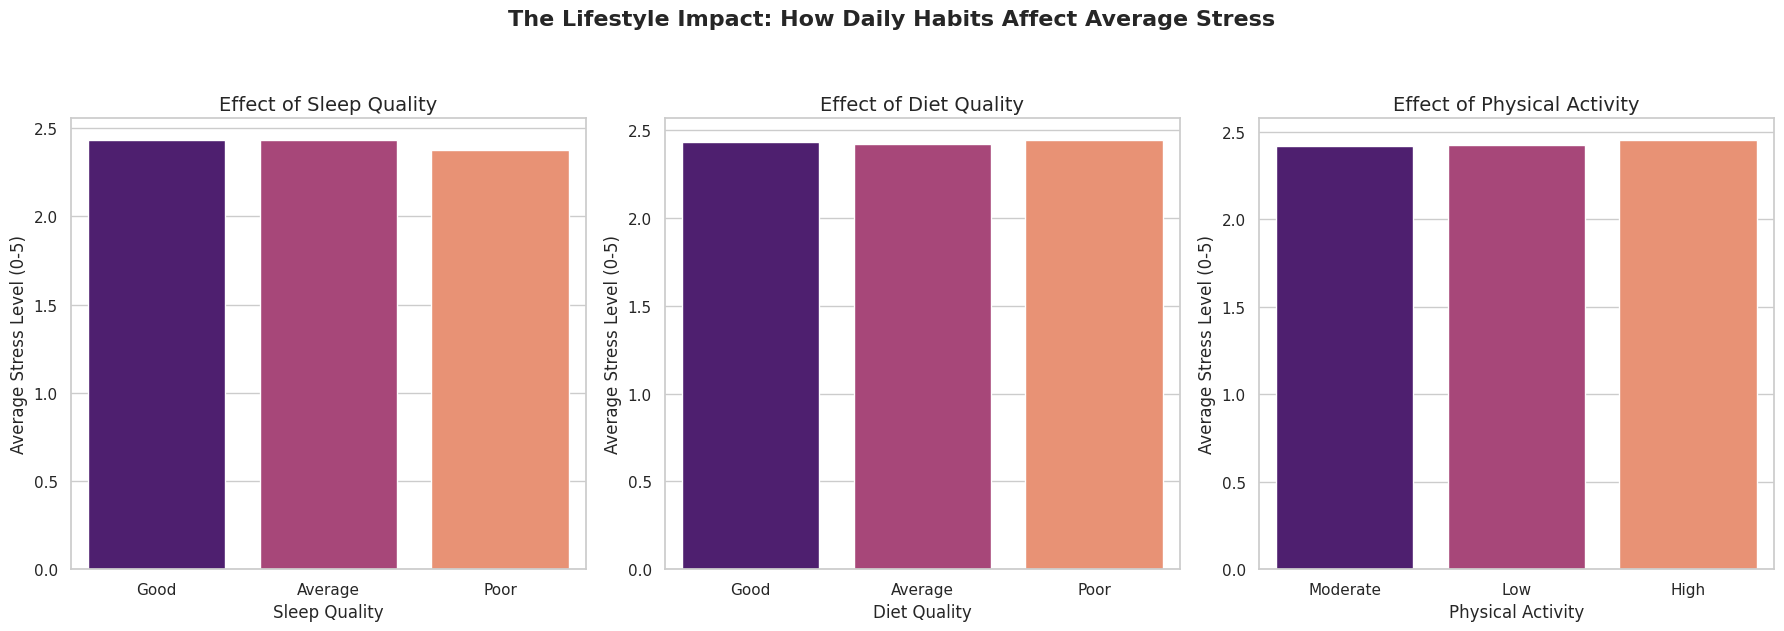

In [15]:
# Set up a clean visual style
sns.set_theme(style="whitegrid")

# Define the lifestyle factors we want to investigate and our target metric
lifestyle_categories = ['Sleep_Quality', 'Diet_Quality', 'Physical_Activity']
primary_target = 'Stress_Level'

# Create a wide figure to hold three side-by-side plots
lifestyle_figure, lifestyle_axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
lifestyle_figure.suptitle('The Lifestyle Impact: How Daily Habits Affect Average Stress', fontsize=16, fontweight='bold', y=1.05)

# Loop through each lifestyle factor to build its respective plot
for index, current_factor in enumerate(lifestyle_categories):

    # Plot the average stress level for each category of the lifestyle factor
    sns.barplot(
        ax=lifestyle_axes[index],
        data=df,
        x=current_factor,
        y=primary_target,
        palette='magma',
        hue=current_factor,
        errorbar=None # Hiding error bars to focus strictly on the average differences
    )

    # Format the titles and labels for readability
    readable_factor_name = current_factor.replace('_', ' ')
    lifestyle_axes[index].set_title(f'Effect of {readable_factor_name}', fontsize=14)
    lifestyle_axes[index].set_xlabel(readable_factor_name, fontsize=12)
    lifestyle_axes[index].set_ylabel('Average Stress Level (0-5)', fontsize=12)

# Ensure the subplots are cleanly spaced
plt.tight_layout()
plt.show()

### **Case 4: Finance & Support**

* Analyze interaction between Financial_Stress, Social_Support and overall Stress_level

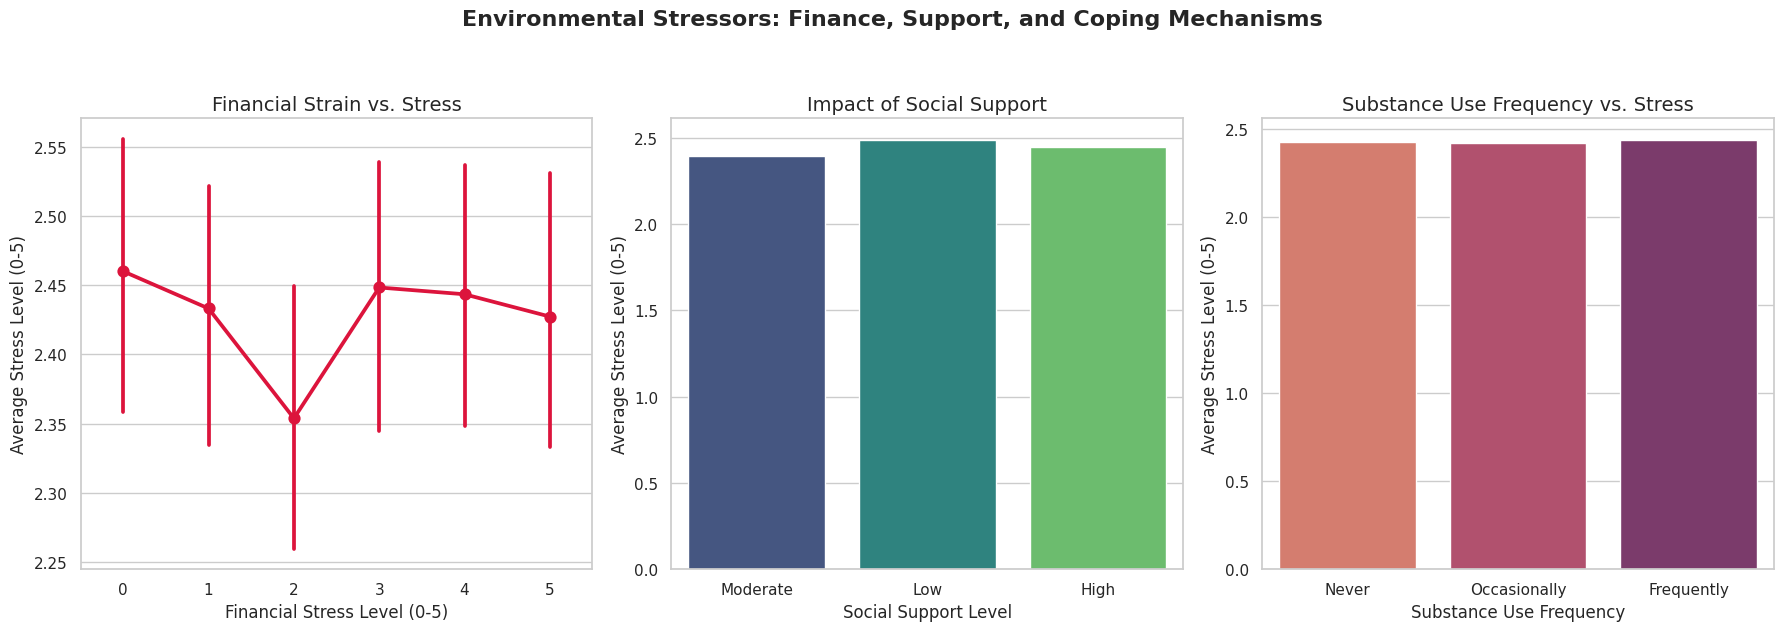

In [16]:
# Set a clean visual style
sns.set_theme(style="whitegrid")

# Create a figure with three subplots side-by-side
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
fig.suptitle('Environmental Stressors: Finance, Support, and Coping Mechanisms', fontsize=16, fontweight='bold', y=1.05)

# --- Plot 1: Financial Stress (Using a point plot to see the trend line) ---
sns.pointplot(
    ax=axes[0],
    data=df,
    x='Financial_Stress',
    y='Stress_Level',
    color='crimson'
)
axes[0].set_title('Financial Strain vs. Stress', fontsize=14)
axes[0].set_xlabel('Financial Stress Level (0-5)', fontsize=12)
axes[0].set_ylabel('Average Stress Level (0-5)', fontsize=12)

# --- Plot 2: Social Support (Using a bar plot for categories) ---
sns.barplot(
    ax=axes[1],
    data=df,
    x='Social_Support',
    y='Stress_Level',
    palette='viridis',
    hue='Social_Support',
    errorbar=None
)
axes[1].set_title('Impact of Social Support', fontsize=14)
axes[1].set_xlabel('Social Support Level', fontsize=12)
axes[1].set_ylabel('Average Stress Level (0-5)', fontsize=12)

# --- Plot 3: Substance Use (Using a bar plot for categories) ---
sns.barplot(
    ax=axes[2],
    data=df,
    x='Substance_Use',
    y='Stress_Level',
    palette='flare',
    hue='Substance_Use',
    errorbar=None
)
axes[2].set_title('Substance Use Frequency vs. Stress', fontsize=14)
axes[2].set_xlabel('Substance Use Frequency', fontsize=12)
axes[2].set_ylabel('Average Stress Level (0-5)', fontsize=12)

# Ensure clean spacing
plt.tight_layout()
plt.show()

### **Case 5: Correlation Matrix**
* To check the mathematical relationships between features

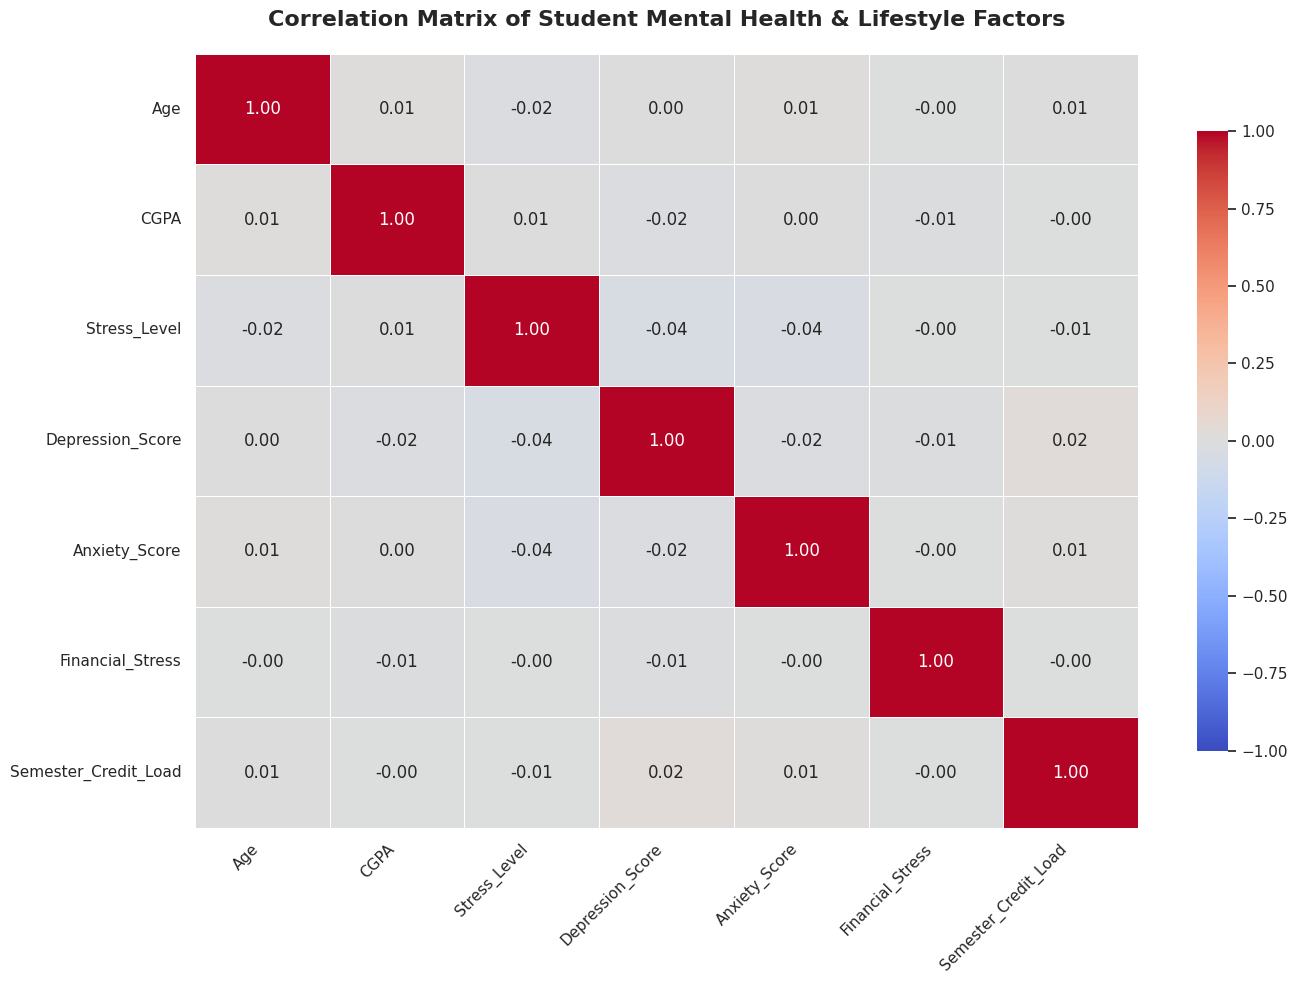

In [17]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(14, 10))
plt.title('Correlation Matrix of Student Mental Health & Lifestyle Factors', fontsize=16, fontweight='bold', pad=20)

# Draw the heatmap
# - annot=True prints the correlation values inside the boxes
# - cmap='coolwarm' gives a nice blue (negative) to red (positive) gradient
# - fmt=".2f" rounds the numbers to two decimal places for readability
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Preprocessing



##Encoding: Converting Categorical Text to Numerical Values



In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Data after Encoding (First 5 rows):")
display(df.head())

Data after Encoding (First 5 rows):


,Age,Course,Gender,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Financial_Stress,Extracurricular_Involvement,Semester_Credit_Load,Residence_Type
0,25,5,1,3.56,3,3,2,1,2,1,2,1,1,1,0,0,2,2,17,1
1,24,2,0,2.44,0,3,0,0,1,0,1,2,2,2,0,0,3,1,27,1
2,19,0,0,3.74,4,0,3,1,1,0,2,0,1,2,0,0,4,0,15,1
3,19,1,1,3.65,2,1,0,0,1,0,2,2,1,1,0,0,4,2,20,0
4,18,0,1,3.40,3,3,4,1,1,0,0,1,1,1,0,1,0,0,23,1


## Calculating the "Stress Index"

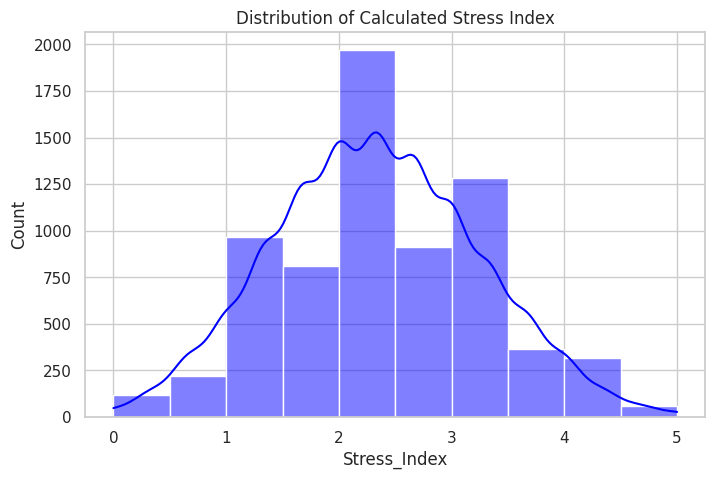

In [19]:
# We combine existing psychological indicators to create a holistic index
df['Stress_Index'] = (df['Stress_Level'] + df['Depression_Score'] + df['Anxiety_Score']) / 3

# Visualizing the newly created Stress Index
plt.figure(figsize=(8, 5))
sns.histplot(df['Stress_Index'], bins=10, kde=True, color='blue')
plt.title('Distribution of Calculated Stress Index')
plt.show()

##Feature Selection

In [20]:
# Feature Selection: Identifying most relevant features for Stress_Level
top_correlations = df.corr()['Stress_Level'].sort_values(ascending=False)
print("Top features correlated with Stress Level:")
print(top_correlations)


Top features correlated with Stress Level:
Stress_Level                   1.000000
Stress_Index                   0.553258
Course                         0.169181
Family_History                 0.019478
Chronic_Illness                0.017232
Residence_Type                 0.013792
Diet_Quality                   0.005641
CGPA                           0.005110
Relationship_Status            0.002715
Gender                         0.002103
Financial_Stress              -0.001388
Substance_Use                 -0.001943
Extracurricular_Involvement   -0.003709
Semester_Credit_Load          -0.005558
Sleep_Quality                 -0.007007
Physical_Activity             -0.007488
Counseling_Service_Use        -0.007959
Social_Support                -0.016815
Age                           -0.019901
Anxiety_Score                 -0.035802
Depression_Score              -0.043313
Name: Stress_Level, dtype: float64


## Binning Stress Index into Categories


In [21]:
# Defining thresholds:
# 0.0 to 2.5 -> Low Stress
# 2.5 to 3.5 -> Medium Stress
# 3.5 to 5.0 -> High Stress
bins = [0, 2.5, 3.5, 5.0]
category_labels = ['Low', 'Medium', 'High']

# Create the new categorical column using pd.cut
df['Stress_Category'] = pd.cut(df['Stress_Index'], bins=bins, labels=category_labels, include_lowest=True)

print("Distribution of Students across Stress Categories:")
print(df['Stress_Category'].value_counts())

# -------------------------------------------------------------------
# Encoding the Target Variable for Machine Learning (XGBoost)
# ML models require numerical targets, so we map Low=0, Medium=1, High=2
# -------------------------------------------------------------------
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Target_Stress_Class'] = df['Stress_Category'].map(target_mapping)

print("\nFirst 5 rows of the new categorized features:")
display(df[['Stress_Index', 'Stress_Category', 'Target_Stress_Class']].head())

Distribution of Students across Stress Categories:
Stress_Category
Low       4085
Medium    2199
High       738
Name: count, dtype: int64

First 5 rows of the new categorized features:


,Stress_Index,Stress_Category,Target_Stress_Class
0,2.666667,Medium,1
1,1.000000,Low,0
2,2.333333,Low,0
3,1.000000,Low,0
4,3.333333,Medium,1


# **Classification Model**

# **Importing Libraries**

In [22]:
!pip install imbalanced-learn

In [23]:
!pip install catboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00


In [24]:
# ML Imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# **Define Features (X) and Target (y)**

In [25]:
# --- 1. Define Features (X) and Target (y) ---
# CRITICAL: Drop data leakage columns and irrelevant identifiers
columns_to_drop = [
    'Stress_Level', 'Depression_Score', 'Anxiety_Score',
    'Stress_Index', 'Stress_Category', 'Target_Stress_Class'
]

# Keep only columns that actually exist in the dataframe
X = df.drop(columns=[col for col in columns_to_drop if col in df.columns], axis=1)
y = df['Target_Stress_Class']

# **Train-Test Split**

In [26]:
# --- 2. Train-Validation-Test Split (with Stratification) ---
# Step 1: Separate 70% for Training and 30% for a Temporary set (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Step 2: Split the 30% Temporary set into 50% Validation and 50% Test
# This results in 15% of the total data for Validation and 15% for Testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\n=== Data Split Summary ===")
print(f"Total Records:  {len(X)}")
print(f"Training Set:   {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Validation Set: {len(X_val)} ({len(X_val)/len(X)*100:.0f}%)")
print(f"Testing Set:    {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")


=== Data Split Summary ===
Total Records:  7022
Training Set:   4915 (70%)
Validation Set: 1053 (15%)
Testing Set:    1054 (15%)


# **Handle Imbalance using SMOTE**

In [27]:
# --- 3. Handle Imbalance (Using Class Weights instead of SMOTE) ---
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

print("\n[INFO] Original Training Class Distribution:")
print(y_train.value_counts().sort_index())

# 1. Calculate perfect mathematical weights based on your ORIGINAL y_train
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

# Create a dictionary of the weights {0: weight, 1: weight, 2: weight}
class_weights_dict = dict(zip(classes, weights))

print("\n[INFO] Calculated Class Weights to handle imbalance:")
print(class_weights_dict)

# Note: We NO LONGER create X_train_balanced.
# We will pass the original X_train and y_train directly into the models.


[INFO] Original Training Class Distribution:
Target_Stress_Class
0    2859
1    1539
2     517
Name: count, dtype: int64

[INFO] Calculated Class Weights to handle imbalance:
{np.int64(0): np.float64(0.5730441879445027), np.int64(1): np.float64(1.0645440762399827), np.int64(2): np.float64(3.168923275306254)}


# **Initialize Models**

In [28]:
# #--- 4. Initialize Models ---
# # XGBoost: Standard gradient boosting, requires mlogloss for multi-class
# xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# # LightGBM: Highly efficient, faster training on large datasets
# lgbm_model = LGBMClassifier(random_state=42, verbose=-1)

# # CatBoost: Excels at complex data, verbose=0 prevents it from printing hundreds of lines during training
# cat_model = CatBoostClassifier(random_state=42, verbose=0)

# # Dictionary to hold models for easy looping
# models = {
#     "XGBoost": xgb_model,
#     "LightGBM": lgbm_model,
#     "CatBoost": cat_model
# }

# ==========================================
# 1. INITIALIZE ALL MODELS
# ==========================================
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42,
                          max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8)

lgbm_model = LGBMClassifier(random_state=42, verbose=-1, max_depth=5, num_leaves=31,
                            learning_rate=0.05, subsample=0.8)

# CRITICAL FIX: Use CatBoost's native 'auto_class_weights' to handle imbalance.
# This bypasses the scikit-learn StackingClassifier cloning bug completely!
cat_model_improved = CatBoostClassifier(random_state=42, verbose=0, depth=5, learning_rate=0.03,
                                        l2_leaf_reg=5, auto_class_weights='Balanced', eval_metric='TotalF1')

mlp_model = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam',
                          max_iter=1000, early_stopping=True, alpha=0.001, random_state=42)

svm_model = SVC(kernel='rbf', C=10.0, gamma='scale', probability=True, random_state=42)

stacking_model = StackingClassifier(
    estimators=[('xgb', xgb_model), ('cat', cat_model_improved), ('lgb', lgbm_model)],
    final_estimator=LogisticRegression(max_iter=1000)
)

models = {
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost": cat_model_improved,
    "Neural Network": mlp_model,
    "SVM": svm_model,
    "Stacking Ensemble": stacking_model
}

# **Train & Evaluate Models**

In [29]:
# Run this BEFORE train_test_split
def add_interaction_features(dataframe):
    df = dataframe.copy()

    # 1. Wellness Index: Combines positive lifestyle habits
    df['Wellness_Index'] = df['Sleep_Quality'] + df['Physical_Activity'] + df['Diet_Quality']

    # 2. Academic Pressure: High credits + high financial stress = danger zone
    df['Academic_Pressure'] = df['Semester_Credit_Load'] * df['Financial_Stress']

    # 3. Support Gap: If credit load is high but social support is low
    df['Support_Gap'] = df['Semester_Credit_Load'] - df['Social_Support']

    # 4. Sleep to Load Ratio: Prevents division by zero
    df['Sleep_to_Load'] = df['Sleep_Quality'] / (df['Semester_Credit_Load'] + 1)

    return df

# Apply it to your main dataframe
df = add_interaction_features(df)

# NOTE: Re-run your train_test_split here using the new df!


[INFO] Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:02:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=============== XGBoost Results ===============
Overall Accuracy: 0.5764

Classification Report:
                   precision    recall  f1-score   support

   Low Stress (0)       0.58      0.99      0.73       613
Medium Stress (1)       0.20      0.01      0.01       330
  High Stress (2)       0.00      0.00      0.00       110

         accuracy                           0.58      1053
        macro avg       0.26      0.33      0.25      1053
     weighted avg       0.40      0.58      0.43      1053



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


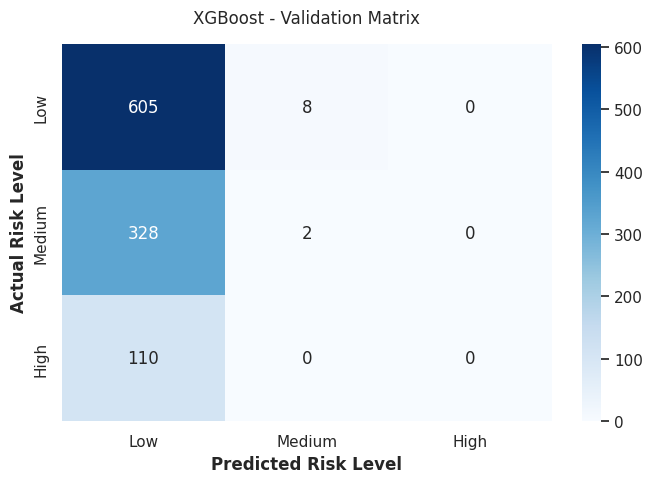


[INFO] Training LightGBM...

=============== LightGBM Results ===============
Overall Accuracy: 0.5651

Classification Report:
                   precision    recall  f1-score   support

   Low Stress (0)       0.58      0.95      0.72       613
Medium Stress (1)       0.28      0.05      0.08       330
  High Stress (2)       0.00      0.00      0.00       110

         accuracy                           0.57      1053
        macro avg       0.29      0.33      0.27      1053
     weighted avg       0.43      0.57      0.44      1053



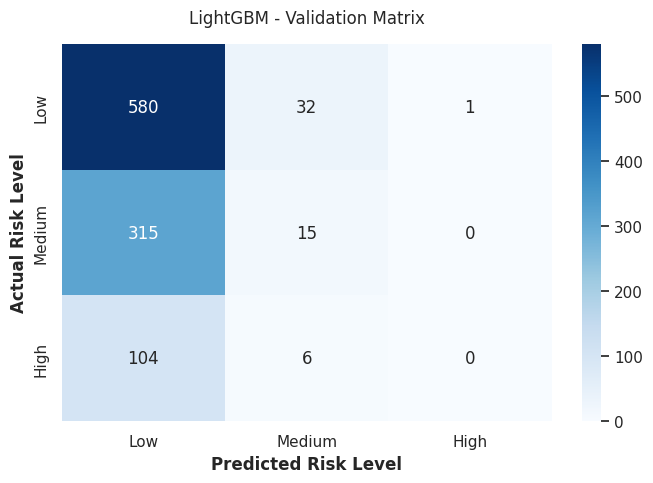


[INFO] Training CatBoost...

=============== CatBoost Results ===============
Overall Accuracy: 0.4255

Classification Report:
                   precision    recall  f1-score   support

   Low Stress (0)       0.63      0.47      0.54       613
Medium Stress (1)       0.34      0.39      0.36       330
  High Stress (2)       0.14      0.26      0.18       110

         accuracy                           0.43      1053
        macro avg       0.37      0.38      0.36      1053
     weighted avg       0.49      0.43      0.45      1053



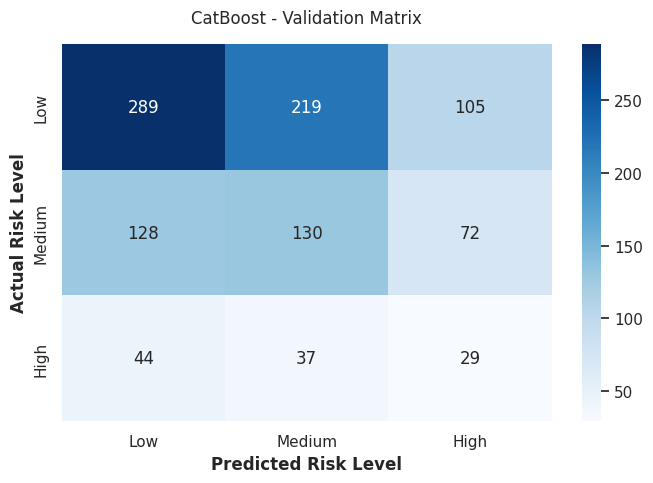


[INFO] Training Neural Network...

=============== Neural Network Results ===============
Overall Accuracy: 0.5821

Classification Report:
                   precision    recall  f1-score   support

   Low Stress (0)       0.58      1.00      0.74       613
Medium Stress (1)       0.00      0.00      0.00       330
  High Stress (2)       0.00      0.00      0.00       110

         accuracy                           0.58      1053
        macro avg       0.19      0.33      0.25      1053
     weighted avg       0.34      0.58      0.43      1053



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


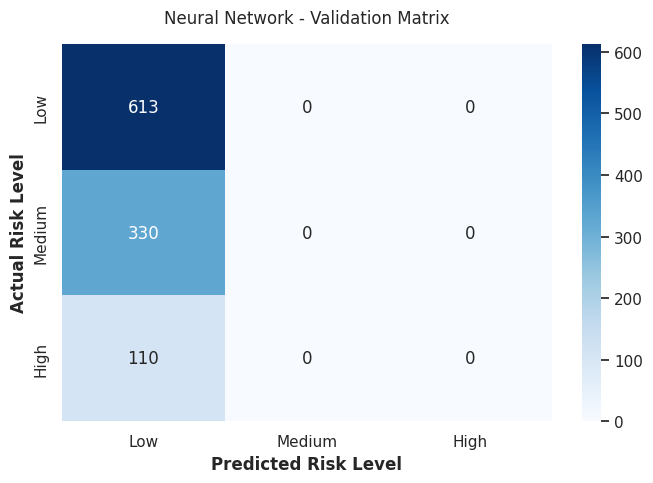


[INFO] Training SVM...

=============== SVM Results ===============
Overall Accuracy: 0.5821

Classification Report:
                   precision    recall  f1-score   support

   Low Stress (0)       0.58      1.00      0.74       613
Medium Stress (1)       0.00      0.00      0.00       330
  High Stress (2)       0.00      0.00      0.00       110

         accuracy                           0.58      1053
        macro avg       0.19      0.33      0.25      1053
     weighted avg       0.34      0.58      0.43      1053



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


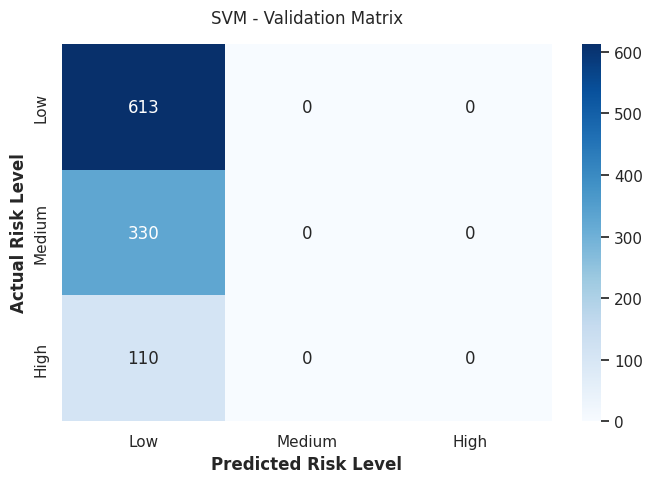


[INFO] Training Stacking Ensemble...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:03:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:03:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:03:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:03:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


=============== Stacking Ensemble Results ===============
Overall Accuracy: 0.5812

Classification Report:
                   precision    recall  f1-score   support

   Low Stress (0)       0.58      1.00      0.74       613
Medium Stress (1)       0.00      0.00      0.00       330
  High Stress (2)       0.00      0.00      0.00       110

         accuracy                           0.58      1053
        macro avg       0.19      0.33      0.25      1053
     weighted avg       0.34      0.58      0.43      1053



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


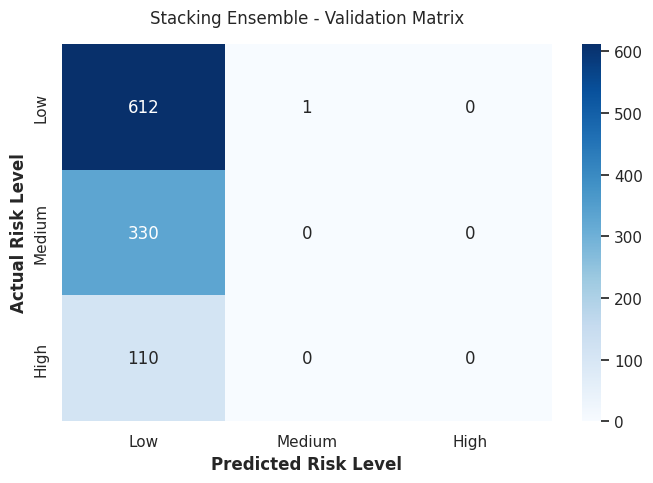

In [30]:
def evaluate_model(model, model_name, X_train, y_train, X_eval, y_eval):
    print(f"\n[INFO] Training {model_name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_eval)

    print(f"\n{'='*15} {model_name} Results {'='*15}")
    print(f"Overall Accuracy: {accuracy_score(y_eval, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_eval, y_pred, target_names=['Low Stress (0)', 'Medium Stress (1)', 'High Stress (2)']))

    plt.figure(figsize=(7, 5))
    cm = confusion_matrix(y_eval, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low', 'Medium', 'High'],
                yticklabels=['Low', 'Medium', 'High'])
    plt.title(f'{model_name} - Validation Matrix', pad=15)
    plt.ylabel('Actual Risk Level', weight='bold')
    plt.xlabel('Predicted Risk Level', weight='bold')
    plt.tight_layout()
    plt.show()

# Loop through our tuned models to train on ORIGINAL data
for name, model in models.items():
    evaluate_model(model, name, X_train, y_train, X_val, y_val)

# **Identify and Store the Best Model**

In [31]:
# --- 6. Identify and Store the Best Model ---
print("\n=== Best Model Selection ===")

best_accuracy = 0
best_model_name = ""
best_model = None

# We loop through the already trained models in your dictionary
for name, model in models.items():
    # Get predictions on the validation set to determine the winner
    y_val_pred = model.predict(X_val)
    current_accuracy = accuracy_score(y_val, y_val_pred)

    # Check if this model is better than the previous best
    if current_accuracy > best_accuracy:
        best_accuracy = current_accuracy
        best_model_name = name
        best_model = model

print(f"The Best Performing Model is: {best_model_name}")
print(f"Validation Accuracy: {best_accuracy:.4f}")


=== Best Model Selection ===
The Best Performing Model is: Neural Network
Validation Accuracy: 0.5821


# **Final Test Set Verification**

In [32]:
# --- 7. Final Test Set Verification ---
# Now we use the 'X_test' (the 15% we never touched) for the ultimate final score
print(f"\n[INFO] Running Final Evaluation of {best_model_name} on Unseen Test Set...")
y_test_pred = best_model.predict(X_test)

print(f"\n{'*'*20} FINAL TEST RESULTS {'*'*20}")
print(f"Final Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print("\nFinal Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Low Stress (0)', 'Medium Stress (1)', 'High Stress (2)']))


[INFO] Running Final Evaluation of Neural Network on Unseen Test Set...

******************** FINAL TEST RESULTS ********************
Final Test Accuracy: 0.5816

Final Test Classification Report:
                   precision    recall  f1-score   support

   Low Stress (0)       0.58      1.00      0.74       613
Medium Stress (1)       0.00      0.00      0.00       330
  High Stress (2)       0.00      0.00      0.00       111

         accuracy                           0.58      1054
        macro avg       0.19      0.33      0.25      1054
     weighted avg       0.34      0.58      0.43      1054



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **Storing Model In Drive**

In [33]:
import joblib
import os

# Define the save path
model_save_path = '/content/drive/MyDrive/best_mental_health_model.pkl'

# Save the best performing model to your Drive
joblib.dump(best_model, model_save_path)

print(f"\nSuccess! The '{best_model_name}' model has been saved permanently to:")
print(model_save_path)


Success! The 'Neural Network' model has been saved permanently to:
/content/drive/MyDrive/best_mental_health_model.pkl


# **Clustering (Student Profiling)**

In [34]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# **Feature Selection & Scaling**

In [35]:
# Using lifestyle and academic factors that define student behavior
cluster_cols = [
    'Semester_Credit_Load', 'Sleep_Quality', 'Physical_Activity',
    'Financial_Stress', 'Social_Support', 'Diet_Quality'
]

X_cluster = df[cluster_cols].copy()

# Scaling is mandatory for distance-based (K-Means/Hierarchical)
# and density-based (DBSCAN) algorithms.
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# **K-means (Centroid-Based Personas)**

In [36]:
print("\n[INFO] Running K-Means...")
# We use 3 clusters to represent Low, Medium, and High Risk behavioral profiles
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_cluster_scaled)

sil_kmeans = silhouette_score(X_cluster_scaled, df['KMeans_Cluster'])
print(f"K-Means Silhouette Score: {sil_kmeans:.4f}")


[INFO] Running K-Means...
K-Means Silhouette Score: 0.1531


# **DBSCAN (Density-Based Outlier Detection)**

In [37]:
print("\n[INFO] Running DBSCAN...")
# eps=0.5 and min_samples=5 are standard starting points for scaled data
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_cluster_scaled)

# Note: DBSCAN labels outliers as -1.
n_clusters_db = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'] else 0)
n_noise_db = list(df['DBSCAN_Cluster']).count(-1)
print(f"DBSCAN found {n_clusters_db} clusters and {n_noise_db} outliers (noise).")


[INFO] Running DBSCAN...
DBSCAN found 315 clusters and 1356 outliers (noise).


# **HIERARCHICAL (Tree-Like Structure)**


[INFO] Generating Hierarchical Dendrogram...


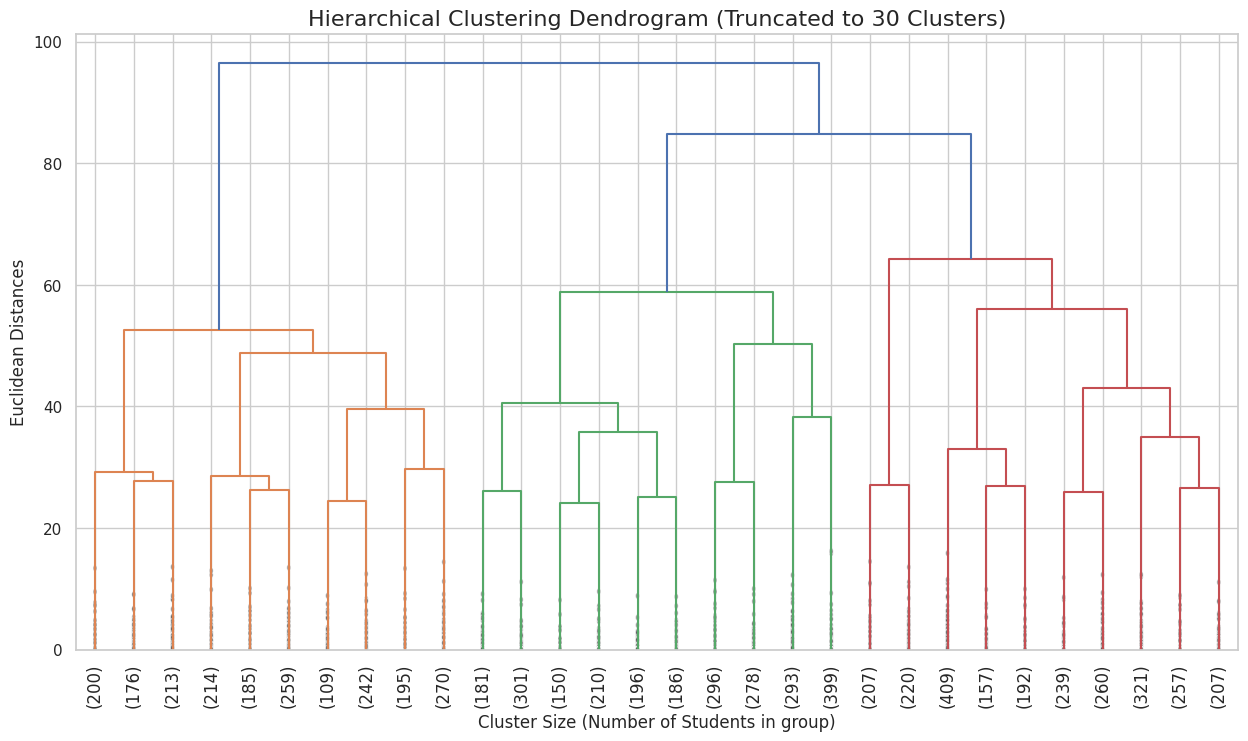

In [38]:
print("\n[INFO] Generating Hierarchical Dendrogram...")
plt.figure(figsize=(15, 8))

# We add 'truncate_mode' and 'p' to show a manageable number of clusters
dendrogram = sch.dendrogram(
    sch.linkage(X_cluster_scaled, method='ward'),
    truncate_mode='lastp',  # Show only the last p merged clusters
    p=30,                   # Show 30 clusters
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True    # Shows dots where branches were collapsed
)

plt.title('Hierarchical Clustering Dendrogram (Truncated to 30 Clusters)', fontsize=16)
plt.xlabel('Cluster Size (Number of Students in group)', fontsize=12)
plt.ylabel('Euclidean Distances', fontsize=12)
plt.show()

# **FINAL VISUALIZATION: Persona Comparison (Heatmap)**

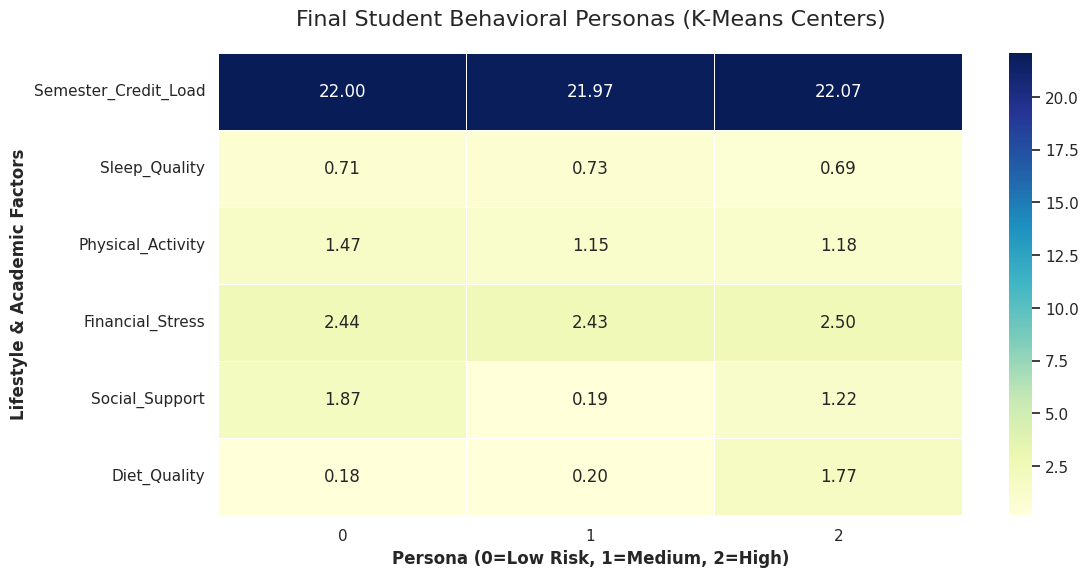

In [39]:
# We profile the K-Means clusters as they provide the most interpretable personas
cluster_profiles = df.groupby('KMeans_Cluster')[cluster_cols].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profiles.T, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)
plt.title('Final Student Behavioral Personas (K-Means Centers)', fontsize=16, pad=20)
plt.xlabel('Persona (0=Low Risk, 1=Medium, 2=High)', fontsize=12, weight='bold')
plt.ylabel('Lifestyle & Academic Factors', fontsize=12, weight='bold')
plt.show()

# **Save Clustering Assets**

In [40]:
import joblib

# 1. Save the K-Means model (to categorize new students into personas)
joblib.dump(kmeans, '/content/drive/MyDrive/student_kmeans_model.pkl')

# 2. Save the Scaler (REQUIRED to process new dashboard inputs)
joblib.dump(scaler, '/content/drive/MyDrive/cluster_scaler.pkl')

# 3. Save the Cluster Profiles (to show the "Average Traits" in the dashboard)
cluster_profiles.to_csv('/content/drive/MyDrive/student_persona_profiles.csv')

print("Clustering assets saved successfully.")

Clustering assets saved successfully.


# **Streamlit**

In [41]:
!pip install -q streamlit
!npm install -q localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 39.9 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹
added 22 packages in 3s
⠹
⠹3 packages are looking for funding
⠹  run `npm fund` for details
⠹

In [42]:
!pip install -q streamlit pyngrok

In [43]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import os

st.set_page_config(page_title="SWIS", layout="wide")
st.title("🎓 SWIS: Student Wellness Intelligence System")

# 1. Load Real Dataset
@st.cache_data
def load_data():
    df = pd.read_csv('/content/drive/MyDrive/students_mental_health_survey.csv')
    df['Student_ID'] = ['STU' + str(i).zfill(4) for i in range(len(df))]
    df = df.dropna(subset=['CGPA', 'Substance_Use'])
    return df

df = load_data()

# 2. Load ML Assets
@st.cache_resource
def load_assets():
    files = ['/content/drive/MyDrive/best_mental_health_model.pkl', '/content/drive/MyDrive/student_kmeans_model.pkl', '/content/drive/MyDrive/cluster_scaler.pkl']
    if not all(os.path.exists(f) for f in files):
        return None, None, None
    return joblib.load(files[0]), joblib.load(files[1]), joblib.load(files[2])

model, kmeans, scaler = load_assets()

# 3. Setup Tabs
tab1, tab2, tab3 = st.tabs(["📂 Dataset Overview", "👤 Individual Student Profile", "🔮 Predictive Analytics"])

# ==========================================
# TAB 1: DATASET OVERVIEW
# ==========================================
with tab1:
    st.header("Overall Population Statistics")

    m1, m2, m3, m4 = st.columns(4)
    m1.metric("Total Students", len(df))
    m2.metric("Average CGPA", round(df['CGPA'].mean(), 2))
    m3.metric("Avg Financial Stress", round(df['Financial_Stress'].mean(), 2))
    m4.metric("Average Credit Load", round(df['Semester_Credit_Load'].mean(), 1))

    st.markdown("---")
    st.subheader("Raw Data View")

    # 1. Let the user choose WHICH columns they want to filter
    filter_cols = st.multiselect(
        "🛠️ Add Custom Filters",
        options=df.columns.tolist(),
        help="Select one or more columns to apply filters."
    )

    # Start with the full dataset
    filtered_df = df.copy()

    # 2. Dynamically generate the right UI widget based on the column's data type
    if filter_cols:
        with st.expander("Filter Options", expanded=True):
            cols = st.columns(min(len(filter_cols), 3))

            for i, col in enumerate(filter_cols):
                curr_col = cols[i % 3]

                with curr_col:
                    # Is it an INTEGER? (e.g., Age, Semester_Credit_Load, Financial_Stress)
                    if pd.api.types.is_integer_dtype(df[col]):
                        min_val = int(df[col].min())
                        max_val = int(df[col].max())

                        user_num_range = st.slider(
                            f"{col}",
                            min_value=min_val,
                            max_value=max_val,
                            value=(min_val, max_val),
                            step=1 # Forces the slider to only use whole numbers
                        )
                        filtered_df = filtered_df[filtered_df[col].between(*user_num_range)]

                    # Is it a FLOAT/DECIMAL? (e.g., CGPA)
                    elif pd.api.types.is_float_dtype(df[col]):
                        min_val = float(df[col].min())
                        max_val = float(df[col].max())
                        step = (max_val - min_val) / 100 if max_val != min_val else 0.1

                        user_num_range = st.slider(
                            f"{col}",
                            min_value=min_val,
                            max_value=max_val,
                            value=(min_val, max_val),
                            step=step
                        )
                        filtered_df = filtered_df[filtered_df[col].between(*user_num_range)]

                    # Is it TEXT/CATEGORICAL? (e.g., Course, Sleep_Quality)
                    else:
                        unique_vals = df[col].dropna().unique()
                        user_cat_selection = st.multiselect(
                            f"{col}",
                            options=unique_vals,
                            default=unique_vals
                        )
                        filtered_df = filtered_df[filtered_df[col].isin(user_cat_selection)]

    # 3. Display the dynamically filtered dataframe
    st.dataframe(filtered_df, use_container_width=True, height=250)

    # --- EDA 2: Academic Pressure & Environmental Stressors ---
    col_eda1, col_eda2 = st.columns(2)
    with col_eda1:
        st.subheader("The Academic Pressure Cooker")
        fig_box = px.box(filtered_df, x='Stress_Level', y='Semester_Credit_Load', color='Stress_Level',
                         title="Impact of Credit Load on Stress", template="plotly_white")
        fig_box.update_layout(showlegend=False)
        st.plotly_chart(fig_box, use_container_width=True)

    with col_eda2:
        st.subheader("Environmental Stressors")
        fin_stress_agg = filtered_df.groupby('Financial_Stress')['Stress_Level'].mean().reset_index()
        fig_line = px.line(fin_stress_agg, x='Financial_Stress', y='Stress_Level', markers=True,
                           title="Financial Stress vs Avg Stress Level", template="plotly_white")
        fig_line.update_traces(marker=dict(size=10, color='crimson'), line=dict(color='crimson', width=3))
        st.plotly_chart(fig_line, use_container_width=True)

    st.markdown("<br>", unsafe_allow_html=True)

    col_c1, col_c2 = st.columns(2)
    with col_c1:
        st.subheader("CGPA Distribution by Sleep Quality")
        fig_hist = px.histogram(filtered_df, x="CGPA", color="Sleep_Quality", barmode="overlay", marginal="box")
        st.plotly_chart(fig_hist, use_container_width=True)

    with col_c2:
        st.subheader("Financial Stress vs Credit Load")
        fig_scatter = px.scatter(filtered_df, x="Semester_Credit_Load", y="Financial_Stress", color="Stress_Level",
                                 size="CGPA", hover_data=['Student_ID', 'Course'])
        st.plotly_chart(fig_scatter, use_container_width=True)

# ==========================================
# TAB 2: INDIVIDUAL STUDENT PROFILE
# ==========================================
with tab2:
    st.header("Deep Dive: Student Stats")

    selected_id = st.selectbox("Search / Select Student ID", options=df['Student_ID'].tolist())

    if selected_id:
        student_data = df[df['Student_ID'] == selected_id].iloc[0]
        st.subheader(f"Profile: {student_data['Student_ID']} ({student_data['Course']})")

        sm1, sm2, sm3, sm4 = st.columns(4)
        sm1.metric("Age", student_data['Age'])
        sm2.metric("CGPA", student_data['CGPA'], delta=round(student_data['CGPA'] - df['CGPA'].mean(), 2))
        sm3.metric("Sleep Quality", student_data['Sleep_Quality'])
        sm4.metric("Financial Stress", student_data['Financial_Stress'], delta=round(student_data['Financial_Stress'] - df['Financial_Stress'].mean(), 2), delta_color="inverse")

        st.markdown("---")
        col_radar, col_violin = st.columns(2)

        with col_radar:
            st.subheader("🕸️ Persona Radar (Student vs Average)")
            sleep_map = {"Poor": 0, "Average": 0.5, "Good": 1}
            student_sleep_val = sleep_map.get(student_data['Sleep_Quality'], 0.5)

            categories = ['Credit Load/30', 'Sleep Quality', 'Finance/5', 'CGPA/4.0']
            student_values = [student_data['Semester_Credit_Load']/30, student_sleep_val, student_data['Financial_Stress']/5, student_data['CGPA']/4.0]
            avg_values = [df['Semester_Credit_Load'].mean()/30, df['Sleep_Quality'].map(sleep_map).mean(), df['Financial_Stress'].mean()/5, df['CGPA'].mean()/4.0]

            fig_radar = go.Figure()
            fig_radar.add_trace(go.Scatterpolar(r=student_values, theta=categories, fill='toself', name=f'{selected_id}'))
            fig_radar.add_trace(go.Scatterpolar(r=avg_values, theta=categories, fill='toself', name='Population Avg', line=dict(dash='dash')))
            fig_radar.update_layout(polar=dict(radialaxis=dict(visible=True, range=[0, 1])), showlegend=True)
            st.plotly_chart(fig_radar, use_container_width=True)

        with col_violin:
            st.subheader("🎻 Population Placement")
            fig_violin = px.violin(df, y="CGPA", x="Stress_Level", color="Stress_Level", box=True, title="CGPA by Stress Level")
            fig_violin.add_trace(go.Scatter(x=[student_data['Stress_Level']], y=[student_data['CGPA']], mode='markers', marker=dict(color='yellow', size=15, symbol='star', line=dict(color='black', width=2)), name=f'{selected_id}'))
            st.plotly_chart(fig_violin, use_container_width=True)

# ==========================================
# TAB 3: PREDICTIVE ANALYTICS
# ==========================================
with tab3:
    st.header("🧠 Predictive Student Sandbox")

    if model is None:
        st.warning("⚠️ Missing .pkl files! Please upload your trained models to the working directory to use the prediction engine.")
    else:
        st.markdown("Adjust the parameters below to simulate a student profile and predict their cluster mapping.")

        # Input Controls inside the tab instead of sidebar
        in1, in2, in3 = st.columns(3)
        with in1:
            age = st.slider("Age", 18, 30, 21)
            credits = st.number_input("Credits", 10, 30, 20)
        with in2:
            cgpa = st.slider("Predicted CGPA Target", 0.0, 4.0, 3.2)
            finance = st.slider("Financial Stress", 0, 5, 3)
        with in3:
            sleep = st.select_slider("Sleep Quality", options=["Poor", "Average", "Good"])

        mapping = {"Poor": 0, "Average": 1, "Good": 2}

        # Logic for calculations
        input_arr = np.array([[credits, mapping[sleep], 1, finance, 1, 1]])
        scaled_input = scaler.transform(input_arr)
        cluster = kmeans.predict(scaled_input)[0]

        st.markdown("---")

        # --- TOP ROW: KPI Metrics ---
        pm1, pm2, pm3 = st.columns(3)
        pm1.metric("Predicted Cluster", f"Cluster {cluster}")
        pm2.metric("Academic Load", f"{credits} Credits")
        pm3.metric("Financial Pressure", f"{finance}/5")

        # --- ROW 2: DYNAMIC VISUALS ---
        p_col_left, p_col_right = st.columns(2)

        with p_col_left:
            st.subheader("🕸️ Simulated Persona Shape")
            categories = ['Credits', 'Sleep', 'Finance', 'Activity', 'Diet']
            values = [credits/30, mapping[sleep]/2, finance/5, 0.5, 0.5]

            fig_sim_radar = go.Figure()
            fig_sim_radar.add_trace(go.Scatterpolar(r=values, theta=categories, fill='toself', name='Simulated Profile'))
            fig_sim_radar.update_layout(polar=dict(radialaxis=dict(visible=True, range=[0, 1])), showlegend=False)
            st.plotly_chart(fig_sim_radar, use_container_width=True)

        with p_col_right:
            st.subheader("🎻 Simulated Placement")
            # Using the real dataset for the background of the simulation violin plot
            fig_sim_violin = px.violin(df, y="CGPA", x="Stress_Level", color="Stress_Level", box=True, points=False,
                                   title="Simulated student vs Actual Population")
            # Mock placing the simulated user on the actual dataset distribution
            mock_stress = int(finance) # Roughly equating finance stress to general stress for visual placement
            if mock_stress == 0: mock_stress = 1

            fig_sim_violin.add_trace(go.Scatter(x=[mock_stress], y=[cgpa], mode='markers', marker=dict(color='white', size=15, symbol='star', line=dict(color='black', width=2)), name='Simulation'))
            st.plotly_chart(fig_sim_violin, use_container_width=True)

        # --- ROW 3: 3D INTERACTIVE ---
        st.subheader("🌌 3D Behavioral Mapping")
        z = np.random.rand(300)
        x = np.random.rand(300)
        y = np.random.rand(300)
        c = np.random.randint(0, 3, 300)

        fig_3d = px.scatter_3d(x=x, y=y, z=z, color=c, opacity=0.3,
                               labels={'x':'Sleep', 'y':'Credits', 'z':'Finance'},
                               title="3D Spatial Positioning of Student Personas")
        st.plotly_chart(fig_3d, use_container_width=True)

Writing app.py


In [44]:
from pyngrok import ngrok
import os

# 1. YOUR ACTION REQUIRED: Paste your NEW token between the quotes below
NGROK_AUTH_TOKEN = "3CLmKTRMyQvtx5Rw3rFmMlOVQSw_2MjGDYX1eDNGiJBMzURpX"

# 2. Set the token
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# 3. Kill any existing ngrok processes to avoid "session limit" errors
ngrok.kill()

# 4. Run the Streamlit app in the background
# CHANGED: Pointing this to the new explorer dashboard!
os.system("streamlit run app.py &")

# 5. Connect the tunnel
try:
    public_url = ngrok.connect(8501)
    print("==================================================")
    print("🚀 SUCCESS! YOUR DASHBOARD IS LIVE")
    print(f"🔗 Click here: {public_url}")
    print("==================================================")
except Exception as e:
    print(f"❌ Error: {e}")

🚀 SUCCESS! YOUR DASHBOARD IS LIVE
🔗 Click here: NgrokTunnel: "https://trial-oversweet-overreach.ngrok-free.dev" -> "http://localhost:8501"
